In [1]:
import os
import re
import json
import torch
import torch.nn as nn
import urllib.request
from collections import Counter, deque
from torch.utils.data import TensorDataset, DataLoader

In [2]:
from datasets import load_dataset

dataset = load_dataset(
    "Salesforce/wikitext",
    "wikitext-2-raw-v1"
)

text_parts = [
    row["text"]
    for row in dataset["train"]
    if row["text"].strip()
]

text = "\n".join(text_parts)

print("Number of characters:", len(text))
print(text[:500])
text = "\n".join(text_parts[:5000])

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…): reconstructing file:   0%|          |  0.00B /  733kB            

wikitext-2-raw-v1/test-00000-of-00001.pa(…): downloading bytes:           |  0.00B            

wikitext-2-raw-v1/train-00000-of-00001.p(…): reconstructing file:   0%|          |  0.00B / 6.36MB            

wikitext-2-raw-v1/train-00000-of-00001.p(…): downloading bytes:           |  0.00B            

...

wikitext-2-raw-v1/validation-00000-of-00(…): downloading bytes:           |  0.00B            

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/36718 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

Number of characters: 10916756
 = Valkyria Chronicles III = 

 Senjō no Valkyria 3 : Unrecorded Chronicles ( Japanese : 戦場のヴァルキュリア3 , lit . Valkyria of the Battlefield 3 ) , commonly referred to as Valkyria Chronicles III outside Japan , is a tactical role @-@ playing video game developed by Sega and Media.Vision for the PlayStation Portable . Released in January 2011 in Japan , it is the third game in the Valkyria series . Employing the same fusion of tactical and real @-@ time gameplay as its predecessors , the story runs p


In [3]:
sentences = [
    [word.lower() for word in re.findall(r"\b\w+\b", sentence)]
    for sentence in re.split(r"[.!?]+", text)
    if sentence.strip()
]


In [4]:
len(sentences)

17412

In [5]:
sentences = [["<bos>"] + i + ["<eos>"] for i in sentences]

In [6]:
sentences[0]

['<bos>',
 'valkyria',
 'chronicles',
 'iii',
 'senjō',
 'no',
 'valkyria',
 '3',
 'unrecorded',
 'chronicles',
 'japanese',
 '戦場のヴァルキュリア3',
 'lit',
 '<eos>']

In [7]:
for i in sentences:
  for j in i:
    print(i,j)
    break
  break

['<bos>', 'valkyria', 'chronicles', 'iii', 'senjō', 'no', 'valkyria', '3', 'unrecorded', 'chronicles', 'japanese', '戦場のヴァルキュリア3', 'lit', '<eos>'] <bos>


In [8]:
# create word vocabulary
word_counts = Counter(word for sentence in sentences for word in sentence)

vocabulary = sorted(word for word, count in word_counts.items())
print(len(vocabulary))

27994


In [9]:
# word vocabulary
special_words = ["<pad>", "<unk>", "<bos>", "<eos>"]

normal_words = sorted(
    word for word in vocabulary
    if word not in special_words
)

word2id = {
    word: id
    for id, word in enumerate(special_words + normal_words)
}

id2word = {id: word for word, id in word2id.items()}


In [10]:
# create char vocabulary

# special tokens (eos and bos arent included)
special_chars = ["<pad>", "<unk>", "<bow>", "<eow>"]

# Collect unique characters from normal words
characters = sorted({
    char
    for sentence in sentences
    for word in sentence
    if word not in {"<bos>", "<eos>"}
    for char in word
})


In [11]:
# char mapping
char2id = {
    token: id
    for id, token in enumerate(special_chars + characters)
}

id2char = {
    id: token
    for token, id in char2id.items()
}

In [12]:
char2id.items()

dict_items([('<pad>', 0), ('<unk>', 1), ('<bow>', 2), ('<eow>', 3), ('0', 4), ('1', 5), ('2', 6), ('3', 7), ('4', 8), ('5', 9), ('6', 10), ('7', 11), ('8', 12), ('9', 13), ('a', 14), ('b', 15), ('c', 16), ('d', 17), ('e', 18), ('f', 19), ('g', 20), ('h', 21), ('i', 22), ('j', 23), ('k', 24), ('l', 25), ('m', 26), ('n', 27), ('o', 28), ('p', 29), ('q', 30), ('r', 31), ('s', 32), ('t', 33), ('u', 34), ('v', 35), ('w', 36), ('x', 37), ('y', 38), ('z', 39), ('²', 40), ('µ', 41), ('º', 42), ('½', 43), ('ß', 44), ('á', 45), ('â', 46), ('ã', 47), ('ä', 48), ('å', 49), ('æ', 50), ('ç', 51), ('è', 52), ('é', 53), ('ê', 54), ('ë', 55), ('í', 56), ('î', 57), ('ñ', 58), ('ó', 59), ('ô', 60), ('ö', 61), ('ø', 62), ('ú', 63), ('ü', 64), ('ā', 65), ('ă', 66), ('ą', 67), ('ć', 68), ('č', 69), ('đ', 70), ('ĕ', 71), ('ę', 72), ('ğ', 73), ('ľ', 74), ('ł', 75), ('ń', 76), ('ō', 77), ('œ', 78), ('ś', 79), ('ş', 80), ('š', 81), ('ţ', 82), ('ū', 83), ('ź', 84), ('ż', 85), ('ǎ', 86), ('ș', 87), ('ț', 88), ('ɑ

In [13]:
len(char2id)

310

In [14]:
# converting every word into char ids

max_word_length = 20

def word_to_char_ids(word, char2id, max_word_length=20):
    # Handle special word tokens
    if word in {"<bos>", "<eos>"}:
        characters = [word]
    else:
        characters = ["<bow>"] + list(word) + ["<eow>"]

    # Convert characters into id
    ids = [
        char2id.get(char, char2id["<unk>"])
        for char in characters
    ]

    # Cut words that are too long
    ids = ids[:max_word_length]

    # Add padding
    ids += [char2id["<pad>"]] * (max_word_length - len(ids))

    return ids

In [15]:
special_chars = ["<pad>","<unk>","<bow>","<eow>","<bos>","<eos>"]


In [16]:
# converting all sentences
char_encoded_sentences = [
    [
        word_to_char_ids(word, char2id, max_word_length)
        for word in sentence
    ]
    for sentence in sentences
]

In [17]:
sentence_index = 0
word_index = 1

print("Word:", sentences[sentence_index][word_index])
print("Character IDs:", char_encoded_sentences[sentence_index][word_index])
print("Length:", len(char_encoded_sentences[sentence_index][word_index]))

Word: valkyria
Character IDs: [2, 35, 14, 25, 24, 38, 31, 22, 14, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Length: 20


In [18]:
# converting character ids to char embb.

char_vocab_size = len(char2id)
char_embedding_dim = 16 # 16 numbers representing every char

char_embedding = nn.Embedding(
    num_embeddings=char_vocab_size,
    embedding_dim=char_embedding_dim,
    padding_idx=char2id["<pad>"]
)

In [19]:
# Padding sentences with max word length
max_sentence_length = max(len(sentence) for sentence in sentences)

max_word_length = 20

all_char_ids = []
all_word_ids = []
sentence_lengths = []

for sentence, char_sentence in zip(
    sentences,
    char_encoded_sentences
):
    sentence_length = len(sentence)
    sentence_lengths.append(sentence_length)

    number_of_padding_words = (
        max_sentence_length - sentence_length
    )

    # Encode words as word IDs
    word_ids = [
        word2id.get(word, word2id["<unk>"])
        for word in sentence
    ]

    # Pad word IDs
    word_ids += (
        [word2id["<pad>"]] * number_of_padding_words
    )

    padded_word = (
        [char2id["<pad>"]] * max_word_length
    )

    # Padding character representations
    padded_char_sentence = (
        char_sentence
        + [padded_word] * number_of_padding_words
    )

    all_word_ids.append(word_ids)
    all_char_ids.append(padded_char_sentence)

In [20]:
# converting to tensor format
word_tensor = torch.tensor(all_word_ids,dtype=torch.long)
char_tensor = torch.tensor(all_char_ids,dtype=torch.long)
length_tensor = torch.tensor(sentence_lengths,dtype=torch.long)

In [21]:
from torch.utils.data import TensorDataset, DataLoader, random_split

dataset = TensorDataset(
    char_tensor,
    word_tensor,
    length_tensor
)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=generator
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

print("Training sentences:", len(train_dataset))
print("Validation sentences:", len(val_dataset))

Training sentences: 13929
Validation sentences: 3483


In [22]:
import torch
import torch.nn as nn


class SimpleELMo(nn.Module):

    def __init__(
        self,
        char_vocab_size,
        char_padding_idx,
        word_vocab_size,
        word_padding_idx,
        char_embedding_dim=16,
        word_embedding_dim=32,
        lstm_hidden_dim=64,
        kernel_size=3
    ):
        super().__init__()

        # Character embedding
        self.char_embedding = nn.Embedding(
            num_embeddings=char_vocab_size,
            embedding_dim=char_embedding_dim,
            padding_idx=char_padding_idx
        )

        # Character CNN
        self.char_cnn = nn.Conv1d(
            in_channels=char_embedding_dim,
            out_channels=word_embedding_dim,
            kernel_size=kernel_size
        )

        # Highway layer
        self.transform = nn.Linear(
            word_embedding_dim,
            word_embedding_dim
        )

        self.gate = nn.Linear(
            word_embedding_dim,
            word_embedding_dim
        )

        # Forward LSTM (left -> right)
        self.forward_lstm = nn.LSTM(
            input_size=word_embedding_dim,
            hidden_size=lstm_hidden_dim,
            batch_first=True
        )

        # Backward LSTM (right -> left)
        self.backward_lstm = nn.LSTM(
            input_size=word_embedding_dim,
            hidden_size=lstm_hidden_dim,
            batch_first=True
        )


        self.forward_head = nn.Linear(
            lstm_hidden_dim,
            word_vocab_size
        )

        self.backward_head = nn.Linear(
            lstm_hidden_dim,
            word_vocab_size
        )

    def reverse_valid_words(self, x, lengths):

        reversed_x = x.clone()

        for index, length in enumerate(lengths.tolist()):
            lengths.detach().cpu().tolist()
            reversed_x[index, :length] = torch.flip(
                x[index, :length],
                dims=[0]
            )

        return reversed_x

    def forward(self, char_ids, lengths):

        batch_size, sentence_length, max_word_length = (char_ids.shape)

        # Flattening sentence and word dimensions
        char_ids = char_ids.reshape(
            batch_size * sentence_length,
            max_word_length
        )

        # Shape:(batch_size * sentence_length, max_word_length)

        # Character embeddings
        embedded = self.char_embedding(char_ids)
        cnn_input = embedded.permute(0, 2, 1)

        cnn_output = torch.relu(self.char_cnn(cnn_input))

        # Max pooling
        word_vectors = torch.max(cnn_output,dim=2).values

        # Highway layer
        transformed = torch.relu(
            self.transform(word_vectors)
        )

        gate_value = torch.sigmoid(
            self.gate(word_vectors)
        )

        word_vectors = (
            gate_value * transformed
            + (1 - gate_value) * word_vectors
        )

        word_vectors = word_vectors.reshape(
            batch_size,
            sentence_length,
            -1
        )

        # Shape:(batch_size, sentence_length, word_embedding_dim)

        # Forward LSTM
        forward_output, _ = self.forward_lstm(
            word_vectors
        )

        # Backward LSTM
        reversed_vectors = self.reverse_valid_words(
            word_vectors,
            lengths
        )

        reversed_backward_output, _ = self.backward_lstm(
            reversed_vectors
        )

        backward_output = self.reverse_valid_words(
            reversed_backward_output,
            lengths
        )

        forward_logits = self.forward_head(forward_output)
        backward_logits = self.backward_head(backward_output)

        # Combining both directions
        contextual_vectors = torch.cat(
            [forward_output, backward_output],
            dim=2
        )

        return {
            "word_vectors": word_vectors,
            "forward_output": forward_output,
            "backward_output": backward_output,
            "contextual_vectors": contextual_vectors,
            "forward_logits": forward_logits,
            "backward_logits": backward_logits
        }

In [23]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = SimpleELMo(
    char_vocab_size=len(char2id),
    char_padding_idx=char2id["<pad>"],
    word_vocab_size=len(word2id),
    word_padding_idx=word2id["<pad>"],
    char_embedding_dim=16,
    word_embedding_dim=32,
    lstm_hidden_dim=64,
    kernel_size=3
).to(device)

print("Device:", device)

Device: cuda


In [24]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-3
)

criterion = nn.CrossEntropyLoss(
    ignore_index=word2id["<pad>"],
    reduction="sum"
)

In [25]:
from tqdm.auto import tqdm

def run_epoch(model, data_loader, training=True):

    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0
    total_correct = 0
    total_predictions = 0

    progress_bar = tqdm(data_loader, desc='Training' if training else 'Validation', leave=False)

    for char_ids, word_ids, lengths in progress_bar:

        char_ids = char_ids.to(device)
        word_ids = word_ids.to(device)
        lengths = lengths.to(device)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):

            outputs = model(char_ids, lengths)

            forward_logits = outputs["forward_logits"]
            backward_logits = outputs["backward_logits"]

            # Forward direction
            forward_predictions = forward_logits[:, :-1, :]
            forward_targets = word_ids[:, 1:]

            # Backward direction
            backward_predictions = backward_logits[:, 1:, :]
            backward_targets = word_ids[:, :-1]

            forward_loss = criterion(
                forward_predictions.reshape(
                    -1,
                    forward_predictions.size(-1)
                ),
                forward_targets.reshape(-1)
            )

            backward_loss = criterion(
                backward_predictions.reshape(
                    -1,
                    backward_predictions.size(-1)
                ),
                backward_targets.reshape(-1)
            )

            forward_mask = (
                forward_targets != word2id["<pad>"]
            )

            backward_mask = (
                backward_targets != word2id["<pad>"]
            )

            number_of_predictions = (
                forward_mask.sum()
                + backward_mask.sum()
            )

            loss_sum = forward_loss + backward_loss
            loss = loss_sum / number_of_predictions

            if training:
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(),
                    max_norm=5.0
                )

                optimizer.step()

        # Forward accuracy
        forward_predicted_ids = forward_predictions.argmax(dim=-1)

        forward_correct = (
            (forward_predicted_ids == forward_targets)
            & forward_mask
        ).sum()

        # Backward accuracy
        backward_predicted_ids = backward_predictions.argmax(dim=-1)

        backward_correct = (
            (backward_predicted_ids == backward_targets)
            & backward_mask
        ).sum()

        total_loss += loss_sum.item()

        total_correct += (
            forward_correct.item()
            + backward_correct.item()
        )

        total_predictions += number_of_predictions.item()

        # Update tqdm progress bar with current loss
        progress_bar.set_postfix(loss=loss.item())

    average_loss = total_loss / total_predictions
    accuracy = total_correct / total_predictions

    return average_loss, accuracy

In [26]:
epochs = 100

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(1, epochs + 1):

    train_loss, train_accuracy = run_epoch(
        model,
        train_loader,
        training=True
    )

    val_loss, val_accuracy = run_epoch(
        model,
        val_loader,
        training=False
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)
    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Accuracy: {train_accuracy * 100:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Accuracy: {val_accuracy * 100:.2f}%"
    )

Training:   0%|          | 0/871 [00:00<?, ?it/s]

Validation:   0%|          | 0/218 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 7.3643 | Train Accuracy: 9.68% | Val Loss: 7.0700 | Val Accuracy: 11.84%


Training:   0%|          | 0/871 [00:00<?, ?it/s]

Validation:   0%|          | 0/218 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/218 [00:00<?, ?it/s]

Epoch 99 | Train Loss: 4.8434 | Train Accuracy: 20.63% | Val Loss: 8.2373 | Val Accuracy: 15.82%


Training:   0%|          | 0/871 [00:00<?, ?it/s]

Validation:   0%|          | 0/218 [00:00<?, ?it/s]

Epoch 100 | Train Loss: 4.8394 | Train Accuracy: 20.67% | Val Loss: 8.2336 | Val Accuracy: 15.76%


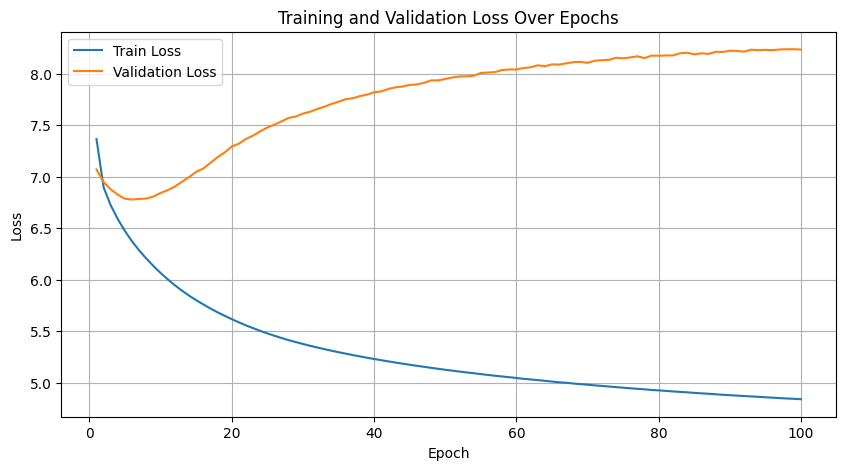

In [27]:
import matplotlib.pyplot as plt

# Plotting Loss
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_losses, label='Train Loss')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

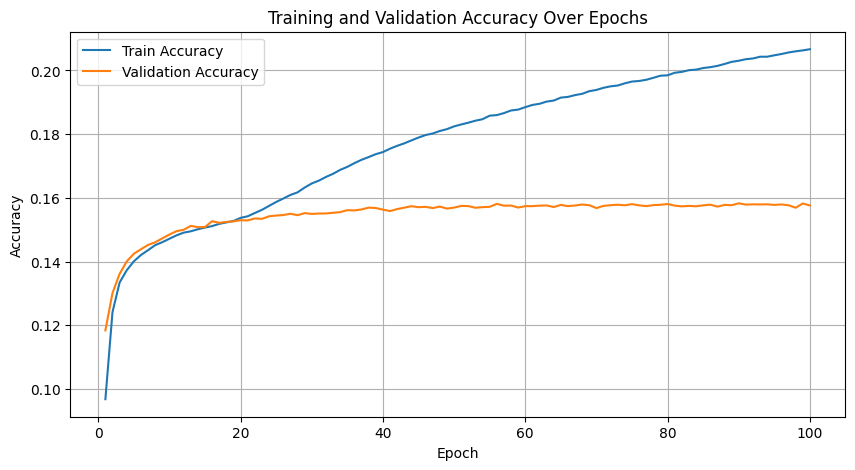

In [28]:
# Plotting Accuracy
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs + 1), train_accuracies, label='Train Accuracy')
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy')
plt.title('Training and Validation Accuracy Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()